数据保存为sales_old.csv，以下是字段及其定义：

- names：客户名称
- age：客户年龄
- total_purchase：购买金额
- account_manager：客户经理，0无客户经理，1有客户经理
- years：客户的总年数
- num_sites：使用服务网站的数量
- onboard_date：登记日期
- location：客户地址
- company：客户公司
- churn：用户流失，0未流失，1已流失，用于监督机器学习的标签

## 1.3.加载数据

In [2]:
import os.path

from pyspark.sql import SparkSession
import pyspark
from pyspark import SparkContext
import findspark
findspark.init()
sc = SparkContext.getOrCreate()

spark = SparkSession.builder.appName('ml_churn').getOrCreate()
spark

In [3]:
from utils.data_path import root_path

# 读取本地csv文件
df = spark.read.csv(os.path.join(root_path(), 'data/user/sales_old.csv'), header=True, inferSchema=True)

### 1.3.1.数据预览

In [3]:
# 查看字段列表
df.columns

['names',
 'age',
 'total_purchase',
 'account_manager',
 'years',
 'num_sites',
 'onboard_date',
 'location',
 'company',
 'churn']

In [4]:
# 查看字段的数据类型
df.dtypes

[('names', 'string'),
 ('age', 'int'),
 ('total_purchase', 'double'),
 ('account_manager', 'int'),
 ('years', 'double'),
 ('num_sites', 'int'),
 ('onboard_date', 'string'),
 ('location', 'string'),
 ('company', 'string'),
 ('churn', 'int')]

In [5]:
# 查看字段名称、数据类型、是否可空等架构信息
df.printSchema()

root
 |-- names: string (nullable = true)
 |-- age: integer (nullable = true)
 |-- total_purchase: double (nullable = true)
 |-- account_manager: integer (nullable = true)
 |-- years: double (nullable = true)
 |-- num_sites: integer (nullable = true)
 |-- onboard_date: string (nullable = true)
 |-- location: string (nullable = true)
 |-- company: string (nullable = true)
 |-- churn: integer (nullable = true)



In [4]:
# 查看前2行数据
df.toPandas().head()

,names,age,total_purchase,account_manager,years,num_sites,onboard_date,location,company,churn
0,Cameron Williams,42,11066.80,0,7.22,8,2013/8/30 7:00,"10265 Elizabeth Mission Barkerburgh, AK 89518",Harvey LLC,1
1,Kevin Mueller,41,11916.22,0,6.50,11,2013/8/13 0:38,"6157 Frank Gardens Suite 019 Carloshaven, RI 1...",Wilson PLC,1
2,Eric Lozano,38,12884.75,0,6.67,12,2016/6/29 6:20,"1331 Keith Court Alyssahaven, DE 90114","Miller, Johnson and Wallace",1
3,Phillip White,42,8010.76,0,6.71,10,2014/4/22 12:43,"13120 Daniel Mount Angelabury, WY 30645-4695",Smith Inc,1
4,Cynthia Norton,37,9191.58,0,5.56,9,2016/1/19 15:31,"765 Tricia Row Karenshire, MH 71730",Love-Jones,1


In [9]:
# 查看指定字段的描述统计信息
cols = ['age', 'total_purchase', 'account_manager', 'years', 'num_sites', 'churn']
df.describe(cols).toPandas().head()

,summary,age,total_purchase,account_manager,years,num_sites,churn
0,count,900,900,900,900,900,900
1,mean,41.81666666666667,10062.82403333334,0.4811111111111111,5.27315555555555,8.587777777777777,0.16666666666666666
2,stddev,6.127560416916251,2408.644531858096,0.4999208935073339,1.274449013194616,1.7648355920350969,0.3728852122772358
3,min,22,100.0,0,1.0,3,0
4,max,65,18026.01,1,9.15,14,1


In [8]:
# 选择数值类型的字段进行描述统计
cols = [i[0] for i in df.dtypes if i[1] in ["int", "double"]]
df.select(cols).toPandas().describe().round(2)

,age,total_purchase,account_manager,years,num_sites,churn
count,900.00,900.00,900.00,900.00,900.00,900.00
mean,41.82,10062.82,0.48,5.27,8.59,0.17
std,6.13,2408.64,0.50,1.27,1.76,0.37
min,22.00,100.00,0.00,1.00,3.00,0.00
25%,38.00,8497.12,0.00,4.45,7.00,0.00
50%,42.00,10045.87,0.00,5.22,8.00,0.00
75%,46.00,11760.10,1.00,6.11,10.00,0.00
max,65.00,18026.01,1.00,9.15,14.00,1.00


### 1.3.2.处理空值

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['font.sans-serif'] = 'SimHei'
plt.rcParams['axes.unicode_minus'] = False
%matplotlib inline

In [6]:
# 转换为pandas的df，可视化使用
pdf = df.toPandas()

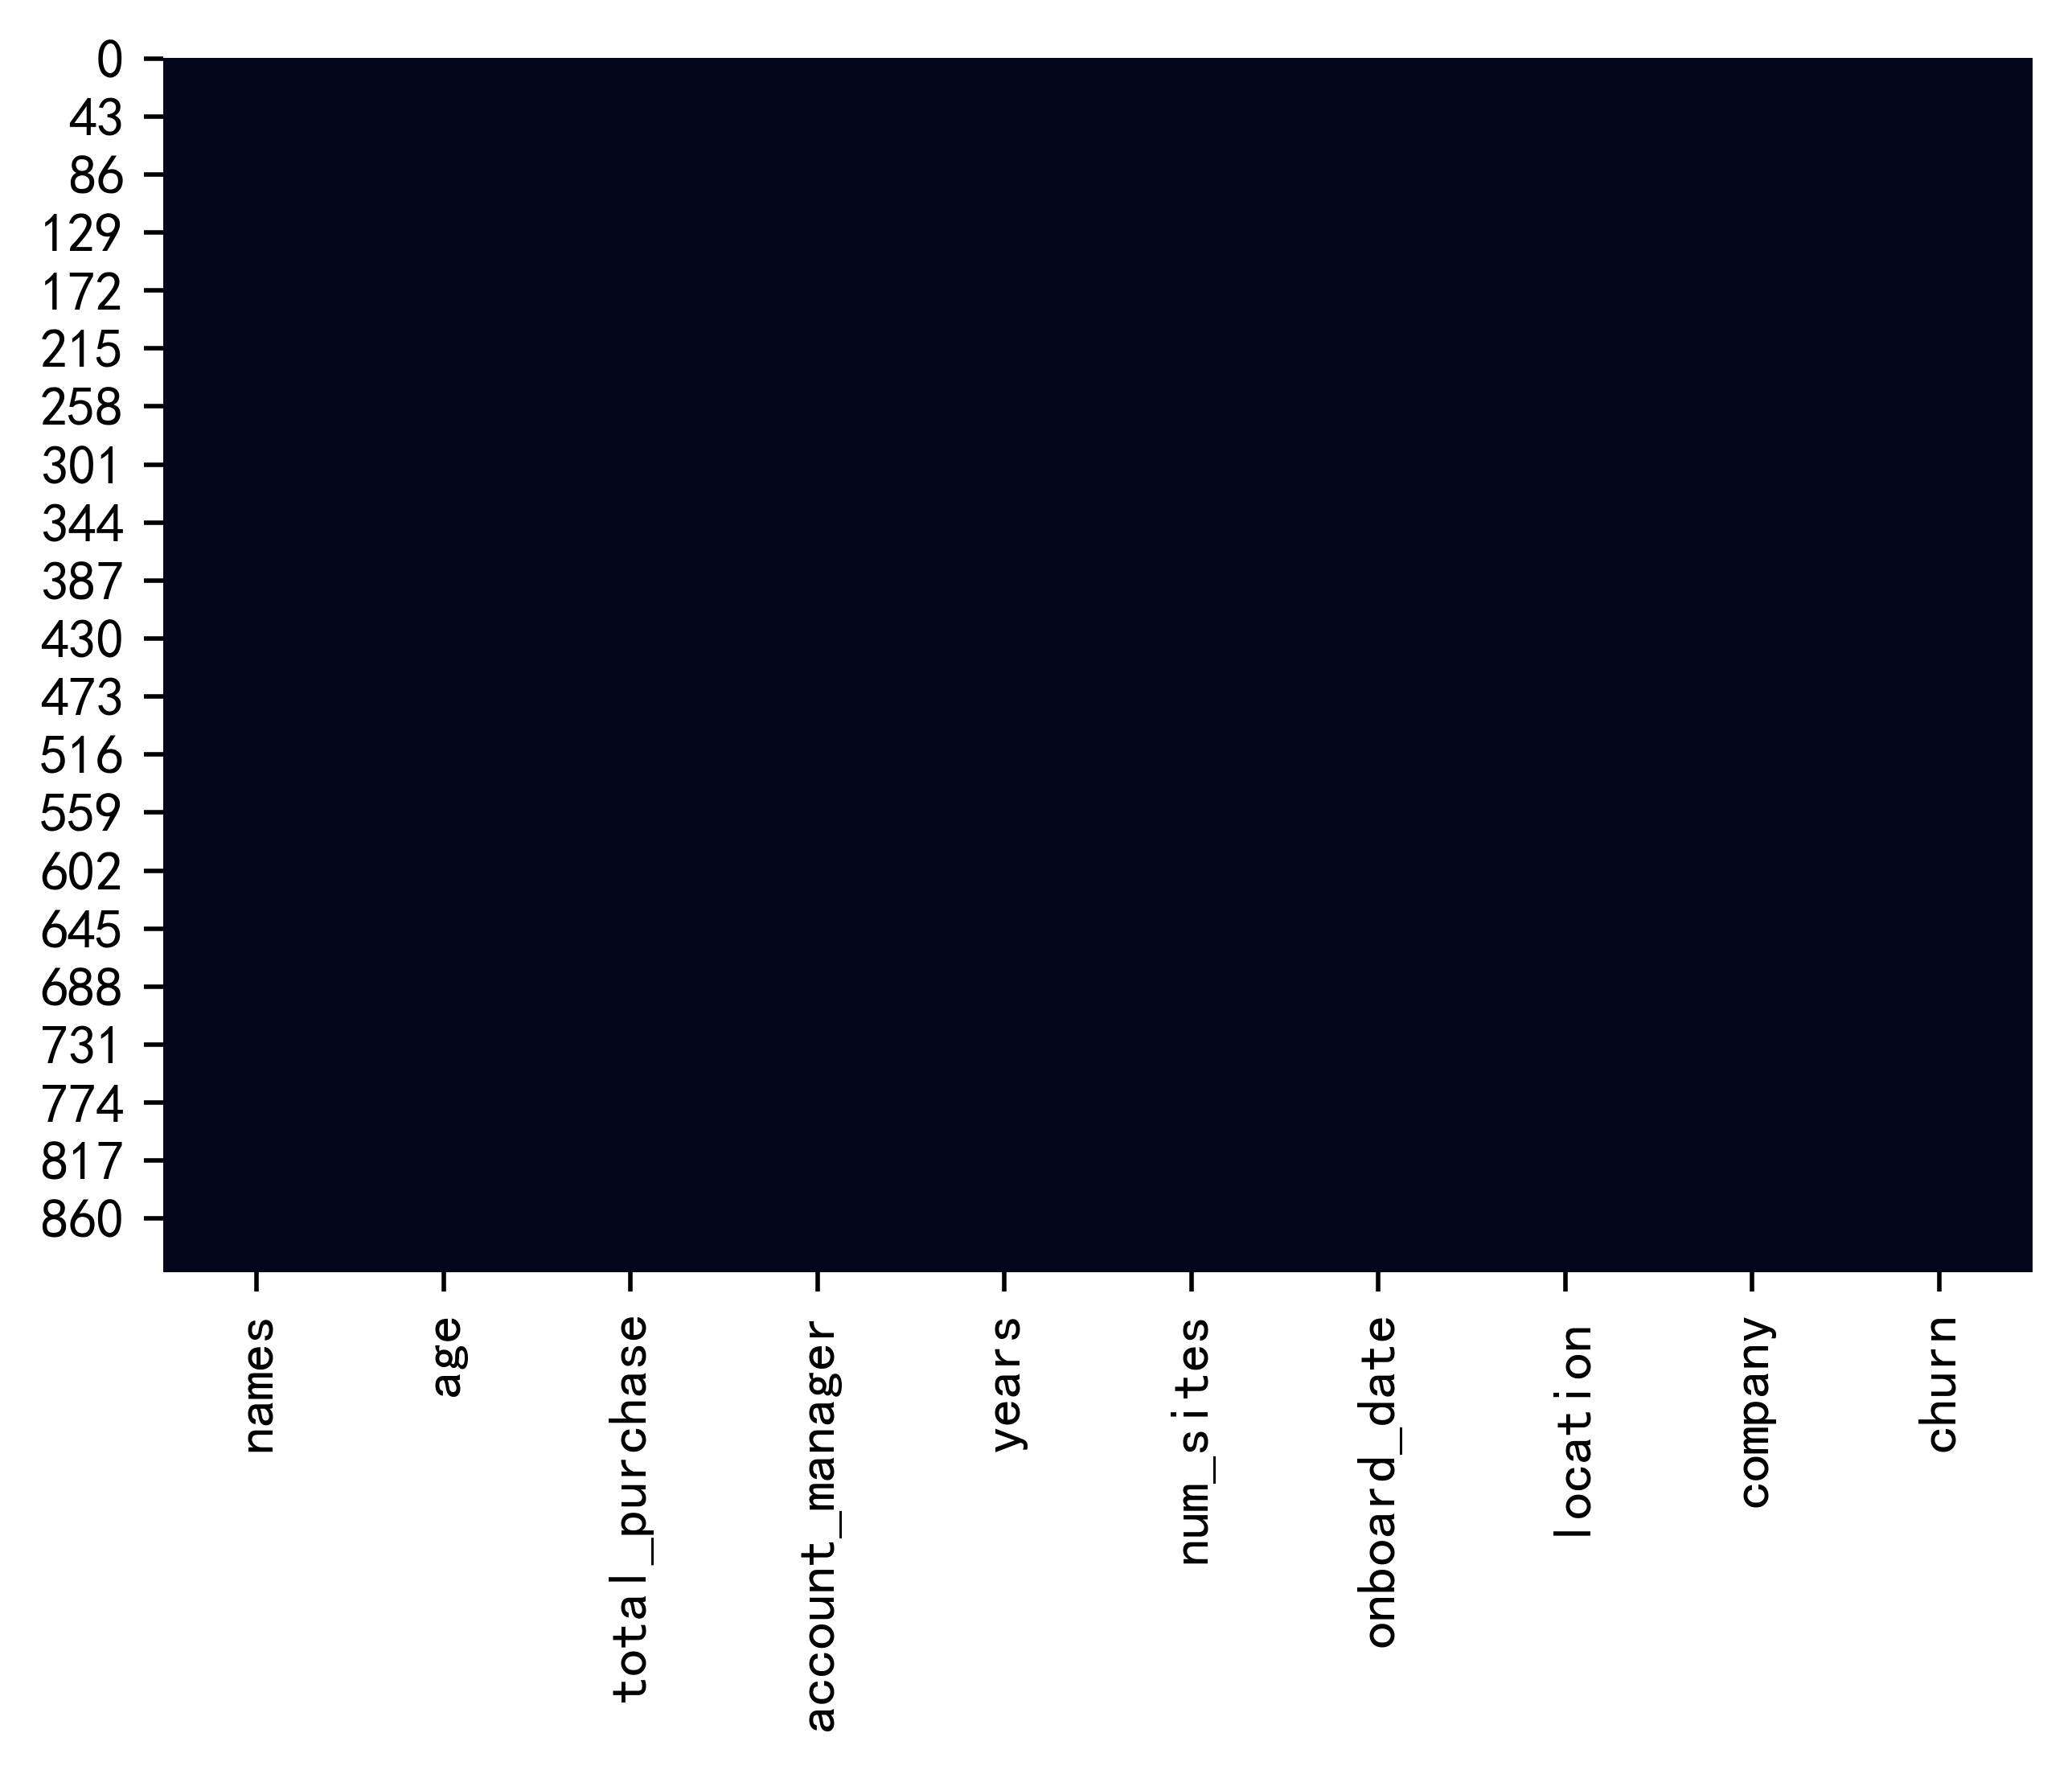

In [5]:
# 通过可视化，查看数据缺失情况
plt.figure(dpi=500)
sns.heatmap(pdf.isnull(), cbar=False)
plt.show()

In [13]:
# 查看指定列的空值数量
df.select('names').filter("churn is null").count()

0

In [14]:
# 删除空值
df.dropna()

# 删除指定列的空值
df.dropna(subset="churn")

DataFrame[names: string, age: int, total_purchase: double, account_manager: int, years: double, num_sites: int, onboard_date: string, location: string, company: string, churn: int]

## 1.4.EDA探索性分析

### 1.4.1.age

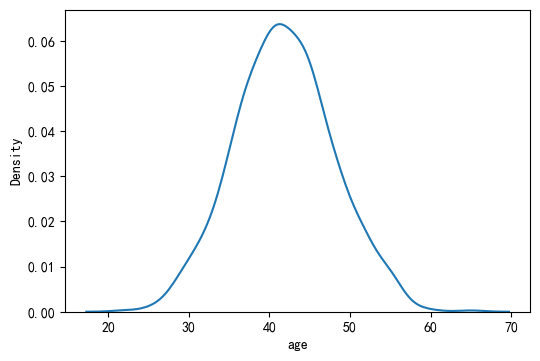

In [15]:
plt.figure(dpi=100)
sns.kdeplot(data=pdf, x='age')
plt.show()

In [16]:
df.groupBy('churn').avg('age').toPandas()

,churn,avg(age)
0,1,42.993333
1,0,41.581333


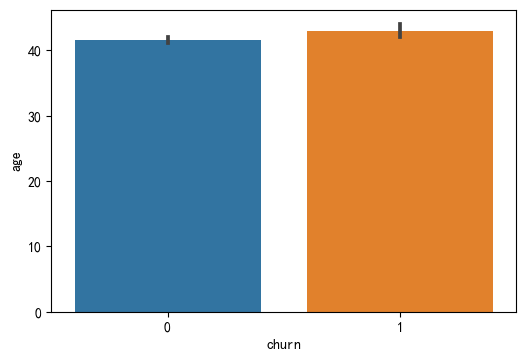

In [17]:
plt.figure(dpi=100)
sns.barplot(data=pdf, x='churn', y='age', estimator=np.mean)
plt.show()

### 1.4.2.total_purchase

In [18]:
df.groupBy('churn').avg('total_purchase').toPandas()

,churn,avg(total_purchase)
0,1,10192.179933
1,0,10036.952853


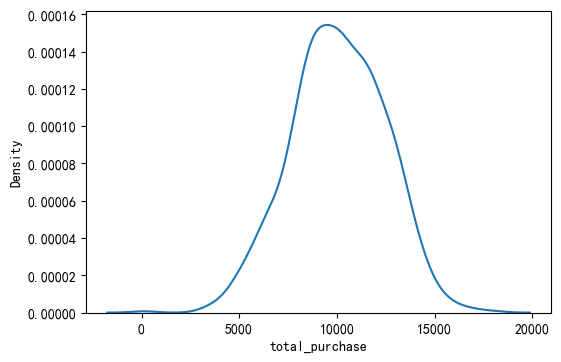

In [19]:
plt.figure(dpi=100)
sns.kdeplot(data=pdf, x='total_purchase')
plt.show()

In [20]:
print('峰度系数', pdf['total_purchase'].kurt())
print('偏度系数', pdf['total_purchase'].skew())

峰度系数 0.004888083117478903
偏度系数 -0.10444105431655137


### 1.4.3.account_manager

In [23]:
temp = df.groupBy('account_manager').count().toPandas()
temp

,account_manager,count
0,1,433
1,0,467


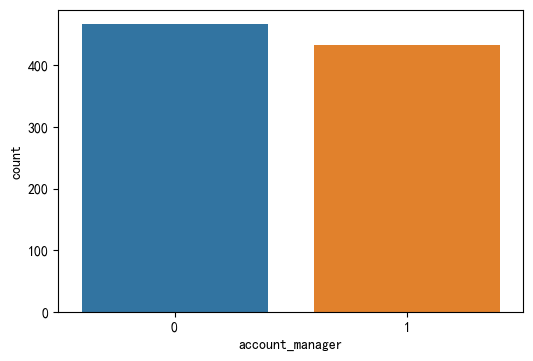

In [24]:
plt.figure(dpi=100)
sns.barplot(data=temp, x='account_manager', y='count')
plt.show()

In [25]:
# 客户流失率
df.groupBy('account_manager').avg('churn').toPandas()

,account_manager,avg(churn)
0,1,0.193995
1,0,0.141328


### 1.4.4.years

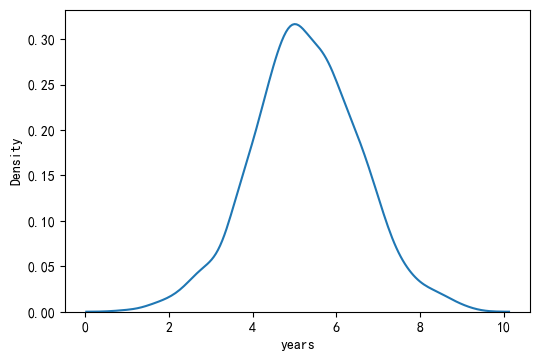

In [26]:
plt.figure(dpi=100)
sns.kdeplot(data=pdf, x='years')
plt.show()

In [27]:
df.groupBy('churn').avg('years').toPandas()

,churn,avg(years)
0,1,5.883600
1,0,5.151067


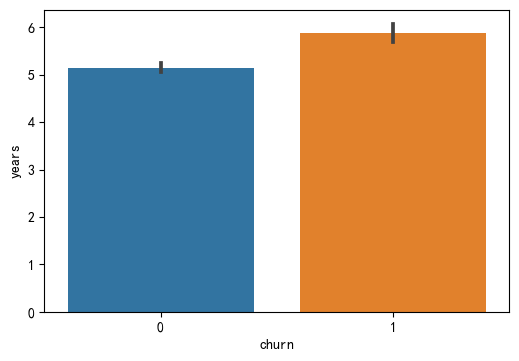

In [28]:
plt.figure(dpi=100)
sns.barplot(data=pdf, x='churn', y='years')
plt.show()

### 1.4.5.num_sites

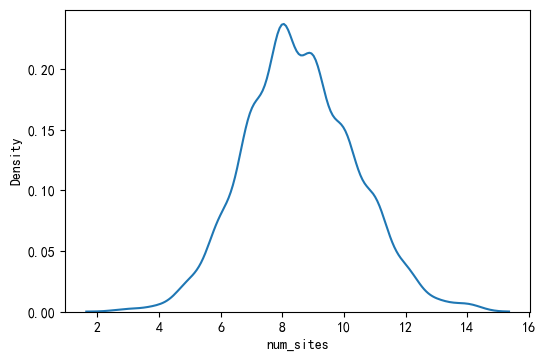

In [29]:
plt.figure(dpi=100)
sns.kdeplot(data=pdf, x='num_sites')
plt.show()

In [30]:
print('峰度系数', pdf['num_sites'].kurt())
print('偏度系数', pdf['num_sites'].skew())

峰度系数 0.1273560402362479
偏度系数 0.18593618902651404


In [31]:
df.groupBy('churn').avg('num_sites').toPandas()

,churn,avg(num_sites)
0,1,10.660000
1,0,8.173333


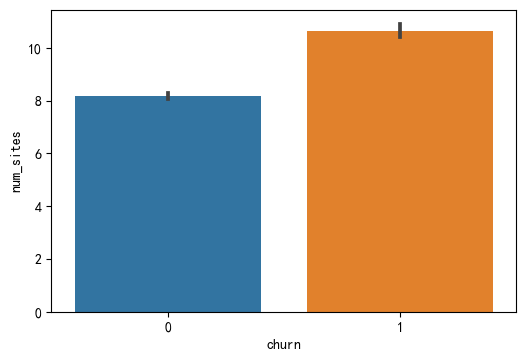

In [32]:
plt.figure(dpi=100)
sns.barplot(data=pdf, x='churn', y='num_sites')
plt.show()

### 1.4.6.company

In [35]:
temp = df.groupBy('company').sum('churn').toPandas()
temp.sort_values(by='sum(churn)',ascending=False).head(5)

,company,sum(churn)
90,Evans LLC,2
221,Smith Inc,2
0,"Miller, Johnson and Wallace",1
229,Tran-Rodriguez,1
703,Shepherd LLC,1


### 1.4.7.相关性分析

#### 热力图

In [37]:
# 相关系数矩阵
data = pdf.corr()
data

,age,total_purchase,account_manager,years,num_sites,churn
age,1.000000,-0.037208,-0.014749,0.005625,-0.006070,0.085926
total_purchase,-0.037208,1.000000,0.015856,-0.005623,-0.003390,0.024031
account_manager,-0.014749,0.015856,1.000000,0.022930,0.033401,0.070611
years,0.005625,-0.005623,0.022930,1.000000,0.051642,0.214329
num_sites,-0.006070,-0.003390,0.033401,0.051642,1.000000,0.525398
churn,0.085926,0.024031,0.070611,0.214329,0.525398,1.000000


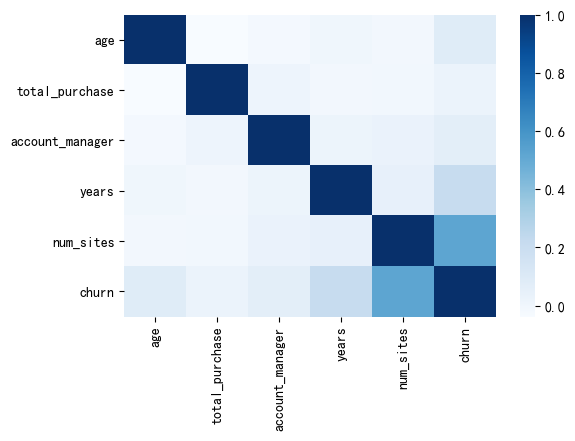

In [38]:
# 如果两个特征变量出现相关系数极高的情况(多重共线性)
# 过滤掉方差/标准差(量纲不一致则计算离散/变异系数)较低的特征, 避免模型过拟合
plt.figure(dpi=100)
sns.heatmap(data=data, cmap='Blues')
plt.show()

#### 散点图

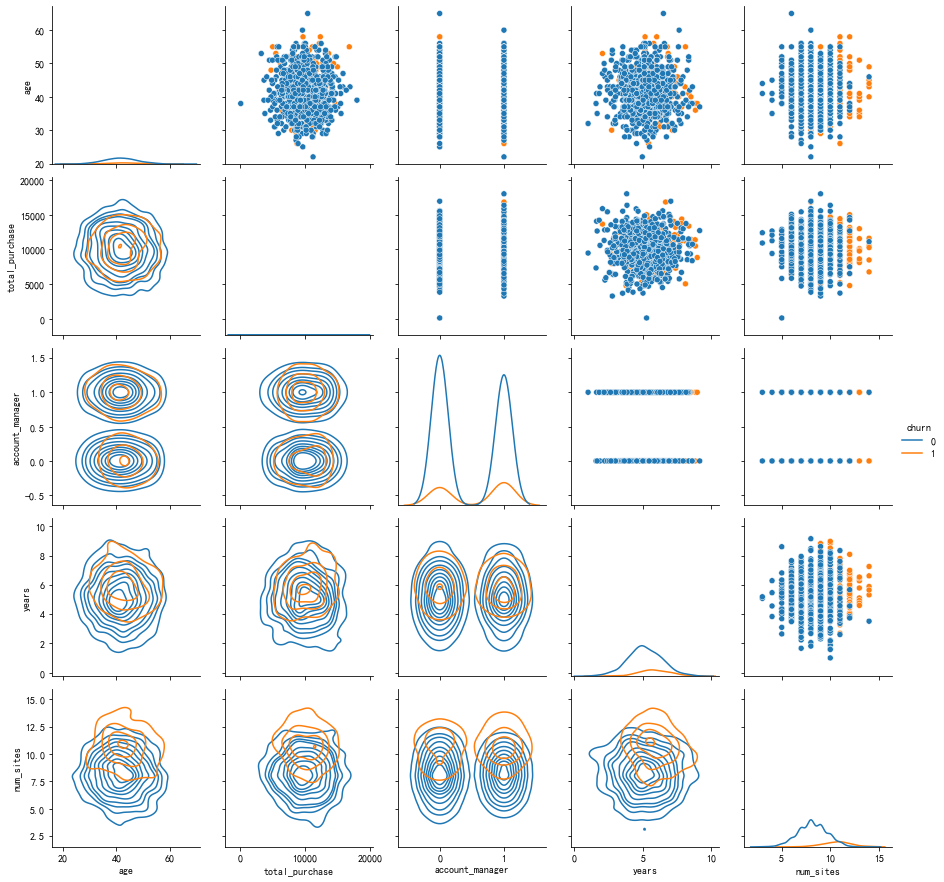

In [40]:
g = sns.PairGrid(data=pdf, hue='churn')
g.map_upper(sns.scatterplot)  # 上三角
g.map_lower(sns.kdeplot)  # 下三角
g.map_diag(sns.kdeplot)  # 对角线
g.add_legend()  # 添加图例
plt.show()

# 2.模型训练

In [7]:
pdf.columns

Index(['names', 'age', 'total_purchase', 'account_manager', 'years',
       'num_sites', 'onboard_date', 'location', 'company', 'churn'],
      dtype='object')

In [8]:
# 导入模型和特征
inputCols = ['age', 'total_purchase', 'account_manager', 'years', 'num_sites']

In [9]:
df.select(inputCols).toPandas().head()

,age,total_purchase,account_manager,years,num_sites
0,42,11066.80,0,7.22,8
1,41,11916.22,0,6.50,11
2,38,12884.75,0,6.67,12
3,42,8010.76,0,6.71,10
4,37,9191.58,0,5.56,9


In [12]:
# 通过VectorAssembler向量汇编器将特征合并为一列
from pyspark.ml.feature import VectorAssembler
assembler = VectorAssembler(inputCols=inputCols, outputCol='features')
trans_df = assembler.transform(df)
trans_df.toPandas().head()

,names,age,total_purchase,account_manager,years,num_sites,onboard_date,location,company,churn,features
0,Cameron Williams,42,11066.80,0,7.22,8,2013/8/30 7:00,"10265 Elizabeth Mission Barkerburgh, AK 89518",Harvey LLC,1,"[42.0, 11066.8, 0.0, 7.22, 8.0]"
1,Kevin Mueller,41,11916.22,0,6.50,11,2013/8/13 0:38,"6157 Frank Gardens Suite 019 Carloshaven, RI 1...",Wilson PLC,1,"[41.0, 11916.22, 0.0, 6.5, 11.0]"
2,Eric Lozano,38,12884.75,0,6.67,12,2016/6/29 6:20,"1331 Keith Court Alyssahaven, DE 90114","Miller, Johnson and Wallace",1,"[38.0, 12884.75, 0.0, 6.67, 12.0]"
3,Phillip White,42,8010.76,0,6.71,10,2014/4/22 12:43,"13120 Daniel Mount Angelabury, WY 30645-4695",Smith Inc,1,"[42.0, 8010.76, 0.0, 6.71, 10.0]"
4,Cynthia Norton,37,9191.58,0,5.56,9,2016/1/19 15:31,"765 Tricia Row Karenshire, MH 71730",Love-Jones,1,"[37.0, 9191.58, 0.0, 5.56, 9.0]"


In [13]:
final_df = trans_df.select('features', 'churn')
final_df.toPandas().head()

,features,churn
0,"[42.0, 11066.8, 0.0, 7.22, 8.0]",1
1,"[41.0, 11916.22, 0.0, 6.5, 11.0]",1
2,"[38.0, 12884.75, 0.0, 6.67, 12.0]",1
3,"[42.0, 8010.76, 0.0, 6.71, 10.0]",1
4,"[37.0, 9191.58, 0.0, 5.56, 9.0]",1


In [14]:
train, test = final_df.randomSplit([0.7, 0.3], seed=666)

In [15]:
from pyspark.ml.classification import LogisticRegression
# 实例化逻辑回归算法, labelCol预测的目标值(标签值)
lr = LogisticRegression(featuresCol='features', labelCol='churn')
# 将数据拆分为训练集和测试集, 70%用来训练模型, 30%用来测试模型
# 使用训练集进行模型训练
model = lr.fit(train)

In [17]:
# 查看模型训练结果
model.summary.predictions.toPandas().head()

D:\python_anaconda\lib\site-packages\pyspark\sql\context.py:125: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(


,features,churn,rawPrediction,probability,prediction
0,"[22.0, 11254.38, 1.0, 4.96, 8.0]",0.0,"[4.330748241960816, -4.330748241960816]","[0.987013178026487, 0.012986821973512974]",0.0
1,"[25.0, 9672.03, 0.0, 5.49, 8.0]",0.0,"[4.327408438378706, -4.327408438378706]","[0.9869702981695673, 0.013029701830432727]",0.0
2,"[26.0, 8787.39, 1.0, 5.42, 11.0]",1.0,"[0.6780911980044415, -0.6780911980044415]","[0.6633125395120745, 0.3366874604879255]",0.0
3,"[26.0, 8939.61, 0.0, 4.54, 7.0]",0.0,"[5.9451432185745965, -5.9451432185745965]","[0.9973883114779338, 0.002611688522066169]",0.0
4,"[27.0, 8628.8, 1.0, 5.3, 7.0]",0.0,"[5.035318988214417, -5.035318988214417]","[0.9935379071994848, 0.00646209280051524]",0.0


In [17]:
# 查看模型训练结果的描述统计信息
model.summary.predictions.describe().show(5)

D:\python_anaconda\lib\site-packages\pyspark\sql\context.py:125: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(


+-------+-------------------+-------------------+
|summary|              churn|         prediction|
+-------+-------------------+-------------------+
|  count|                639|                639|
|   mean| 0.1705790297339593|0.12050078247261346|
| stddev|0.37643536323564897|0.32580125427595885|
|    min|                0.0|                0.0|
|    max|                1.0|                1.0|
+-------+-------------------+-------------------+



# 3.模型评估

In [22]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator
evaluator = BinaryClassificationEvaluator(
    rawPredictionCol='prediction',labelCol='churn')
result = model.evaluate(test)
auc = evaluator.evaluate(result.predictions)
# ROC曲线, 接受者操作特征曲线
# AUC: ROC曲线下方的面积大小
# 混淆矩阵
auc

0.8400221729490023

# 4.保存模型

In [23]:
from pyspark.ml import Pipeline
pipeline = Pipeline(stages=[assembler, lr])
train, test = df.randomSplit([0.7, 0.3], seed=666)
model = pipeline.fit(train)

In [25]:
w = model.write()
w.save(os.path.join(root_path(), 'data/user/lr_churn'))

# 5.预测新客户

In [27]:
new = spark.read.csv('../data/sales_new.csv', inferSchema=True, header=True)
new.toPandas().head()

,names,age,total_purchase,account_manager,years,num_sites,onboard_date,location,company
0,Andrew Mccall,37,9935.53,1,7.71,8,2011/8/29 18:37,"38612 Johnny Stravenue Nataliebury, WI 15717-8316",King Ltd
1,Michele Wright,23,7526.94,1,9.28,15,2013/7/22 18:19,"21083 Nicole Junction Suite 332, Youngport, ME...",Cannon-Benson
2,Jeremy Chang,65,100.00,1,1.00,15,2006/12/11 7:48,"085 Austin Views Lake Julialand, WY 63726-4298",Barron-Robertson
3,Megan Ferguson,32,6487.50,0,9.40,14,2016/10/28 5:32,"922 Wright Branch North Cynthialand, NC 64721",Sexton-Golden
4,Taylor Young,32,13147.71,1,10.00,8,2012/3/20 0:36,Unit 0789 Box 0734 DPO AP 39702,Wood LLC


In [28]:
from pyspark.ml import PipelineModel
model_local = PipelineModel.load(os.path.join(root_path(), 'data/user/lr_churn'))
result = model_local.transform(new)
result.select('names', 'prediction').toPandas().head()

+--------------+----------+
|         names|prediction|
+--------------+----------+
| Andrew Mccall|       0.0|
|Michele Wright|       1.0|
|  Jeremy Chang|       1.0|
|Megan Ferguson|       1.0|
|  Taylor Young|       0.0|
| Jessica Drake|       1.0|
+--------------+----------+



In [30]:
result.columns

['names',
 'age',
 'total_purchase',
 'account_manager',
 'years',
 'num_sites',
 'onboard_date',
 'location',
 'company',
 'features',
 'rawPrediction',
 'probability',
 'prediction']

In [32]:
result.select('names', 'prediction').toPandas().head()

,names,prediction
0,Andrew Mccall,0.0
1,Michele Wright,1.0
2,Jeremy Chang,1.0
3,Megan Ferguson,1.0
4,Taylor Young,0.0
